In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Titanic Survival Prediction

This project focuses on building machine learning models to predict whether a passenger survived the Titanic disaster. The task is formulated as a **binary classification problem**, where the model predicts whether a passenger survived (1) or did not survive (0) based on available information.

The first stage of the project focuses on **data preprocessing and exploratory analysis**.
The dataset contains missing values and several categorical variables stored as strings, therefore multiple preprocessing steps were required. These include handling missing values and transforming categorical features into numerical representations using techniques such as **one-hot encoding** and **binary encoding**, so that the data can be used by machine learning models.

After cleaning the dataset, a **baseline model (Dummy Classifier)** was created to establish a simple reference point for model performance. This allows comparison with more advanced models and ensures that the trained models perform better than naive predictions.

Next, several machine learning models were trained and evaluated to analyze their performance on this task. The experiments include tuning selected hyperparameters and observing how they affect classification metrics. Model performance is evaluated using appropriate metrics for classification problems, and the results are analyzed to better understand the strengths and limitations of different approaches.

The goal of this project is not only to build predictive models, but also to demonstrate the full **machine learning workflow**, including data cleaning, feature preparation, model training, evaluation, and interpretation of results.

# Part I. Data Analysis and Preprocessing
My aim is to analyze and process the dataset so that it can later be used to train a model to classify each passenger as survivor (1) or non-survivor (0).

In [2]:
titanic_df = pd.read_csv('data/titanic.csv', index_col='PassengerId')
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Type conversion

In [3]:
print(titanic_df.dtypes)
titanic_df = titanic_df.convert_dtypes()
print(titanic_df.dtypes)

Survived      int64
Pclass        int64
Name            str
Sex             str
Age         float64
SibSp         int64
Parch         int64
Ticket          str
Fare        float64
Cabin           str
Embarked        str
dtype: object
Survived      Int64
Pclass        Int64
Name         string
Sex          string
Age         Float64
SibSp         Int64
Parch         Int64
Ticket       string
Fare        Float64
Cabin        string
Embarked     string
dtype: object


## Cleaning NaN values
At first, I checked what is the percentage of missing values in each column. My conclusions were as follows:
- in `Cabin` column there is too much NaN values, and it shouldn't be important in classifying, can be deleted
- `Embarked`, `Fare` and `Age` columns will be investigated to fill them with appropriate values

It's unfortunate that there are so many Nans in `Cabin` column, as each record also contains information about the deck. There were 10 decks in Titanic, each located on different level, and this could be useful for predictions. For example, passengers on lower decks may have had a longer path to reach the upper levels, potentially reducing their chances of survival.

In [4]:
def get_percentage_of_nan(dataset, axis):
    missing_vals = dataset.isna().sum(axis=axis)
    return np.round(missing_vals / dataset.shape[axis] * 100, 2)

In [5]:
print(get_percentage_of_nan(titanic_df, 0))

Survived     0.00
Pclass       0.00
Name         0.00
Sex          0.00
Age         19.87
SibSp        0.00
Parch        0.00
Ticket       0.00
Fare        11.00
Cabin       77.10
Embarked     0.22
dtype: float64


### Dropping the column Cabin

In [6]:
titanic_df.drop(columns='Cabin', inplace=True)

### Filling NaNs in the Embarked column
`Embarked` is a categorical type column. I will replace NaNs with the most frequent value "S"

In [7]:
titanic_df.groupby("Embarked").size()

Embarked
C    168
Q     77
S    644
dtype: int64

In [8]:
mask = titanic_df['Embarked'].isna()
titanic_df.loc[mask, 'Embarked'] = 'S'

### Filling NaNs in the `Age` column
The distribution is right-skewed as seen on the plot. mode < median < mean. Median is more robust to outliers on the right side, so it better reflects the tendency of the data. Therefore, I will fill NaNs values with median.

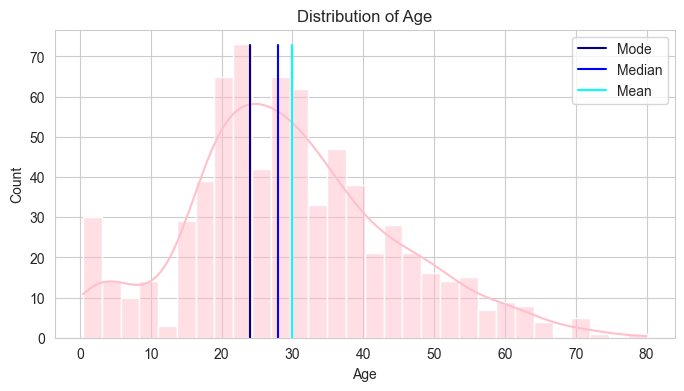

In [9]:
def draw_distribution(dataset, column):
    median = np.round(dataset[column].median())
    mean = np.round(dataset[column].mean())
    mode = np.round(dataset[column].mode()[0])

    plt.figure(figsize=(8, 4))
    sns.histplot(dataset[column], kde=True, bins=30, color='pink')

    plt.axvline(mode, 0, 0.95, color='darkblue', label='Mode')
    plt.axvline(median, 0, 0.95, color='blue', label='Median')
    plt.axvline(mean, 0, 0.95, color='cyan', label='Mean')

    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

draw_distribution(titanic_df, 'Age')

In [10]:
mediana = titanic_df['Age'].median()
titanic_df['Age'] = titanic_df['Age'].fillna(mediana)

### Filling NaNs in the `Fare` column
Column `Fare` is highly right-skewed and contains extreme outliers (some very expensive tickets) that extremely affect the mean. Therefore, I will fill Naa values with the median.

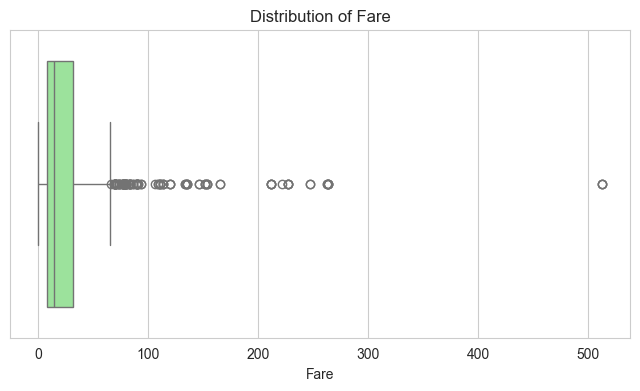

In [11]:
def boxplot(dataset, column):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=dataset[column].dropna(), color='lightgreen')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.show()

boxplot(titanic_df, 'Fare')

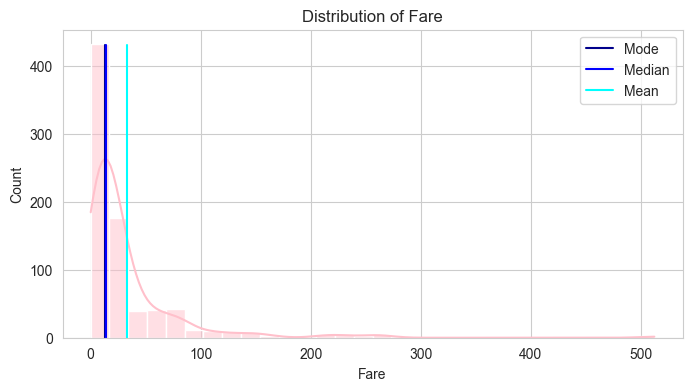

In [12]:
draw_distribution(titanic_df, 'Fare')
mediana = titanic_df['Fare'].median()
titanic_df['Fare'] = titanic_df['Fare'].fillna(mediana)

## Feature Engineering
### `FamilySize` Column = `SibSp` + `Parch` + 1
The `FamilySize` feature represents how many family members are travelling with the passenger. It can be associated with survival, passengers travelling alone could have lower chances of survival. Conversely, very big families could also have reduced survival chance, as they may have problems with coordinating.

In [13]:
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1

### `IsAlone` Column
As stated previously, alone passengers may have decreased survival.

In [14]:
titanic_df['IsAlone'] = titanic_df['FamilySize'] == 1
titanic_df['IsAlone'] = titanic_df['IsAlone'].astype(int)

## Categorical data encoding
Columns `Name` and `Ticket` don't bring much information correlated to survival. Therefore, they can be deleted to not distract the model.
### Dropping Columns `Name` and `Ticket`

In [15]:
titanic_df.drop(columns='Name', inplace=True)
titanic_df.drop(columns='Ticket', inplace=True)

### Binary Encoding of the `Sex` Column

In [16]:
titanic_df['Sex'] = titanic_df['Sex'].map({
    'female': 1, 'male': 0
})

### One hot encoding of the `Embarked` Column
It contains one of three values: 'C', 'Q' and 'S'. Since there is no order between categories, they shouldn't be encoded with integers, as it could confuse the model. Therefore, I will use one hot encoding.

In [17]:
titanic_df = pd.get_dummies(data=titanic_df, prefix='Embarked', columns=['Embarked'], dtype=np.int64)

## Data visualisation
At first, I want to show `Age` and `Fare` relationship. As we can see, the outliers (very high `Fare values) occur only at about 35 years old.

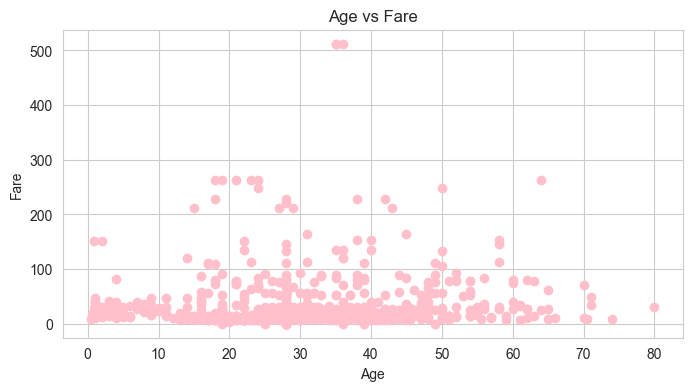

In [18]:
plt.figure(figsize=(8,4))
plt.scatter(titanic_df['Age'], titanic_df['Fare'], color='pink')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare')
plt.show()

I want to show how many people survived or did not survive depending on gender. As shown below, significantly more women survived than did not, unlike men. This suggests that being a woman significantly increased the chances of survival.

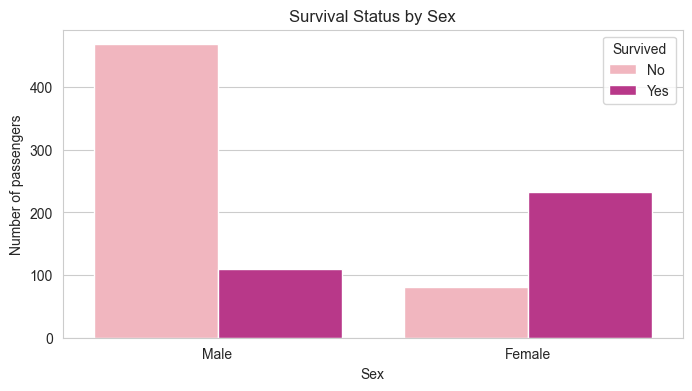

There was 4.0 times more non-survivors than survivors among men.


In [19]:
titanic_mapped = titanic_df.copy()
titanic_mapped['Survived'] = titanic_mapped['Survived'].map({
    0:"No",
    1:"Yes"
})
df_grouped = titanic_mapped.groupby(['Survived', 'Sex']).size().reset_index(name='Count')
plt.figure(figsize=(8,4))
sns.barplot(df_grouped, x='Sex', y='Count', hue='Survived', palette='RdPu')
plt.ylabel('Number of passengers')
plt.xticks(ticks=[0,1],labels=['Male', 'Female'])
plt.title('Survival Status by Sex')
plt.show()

# Counting male survived vs not survived
male = df_grouped.loc[df_grouped['Sex'] == 0]
ratio = male.loc[0, 'Count']  / male.loc[2, 'Count']
print(f"There was {np.round(ratio)} times more non-survivors than survivors among men.")

Another correlation between data can be correlation between `Class` and `Survival`. The higher class, the wealthier the person. The plot shows, that people in 1st class had the highest survival ratio, and people in 3rd class the lowest.

Text(0.5, 1.0, 'Survival Status by Class')

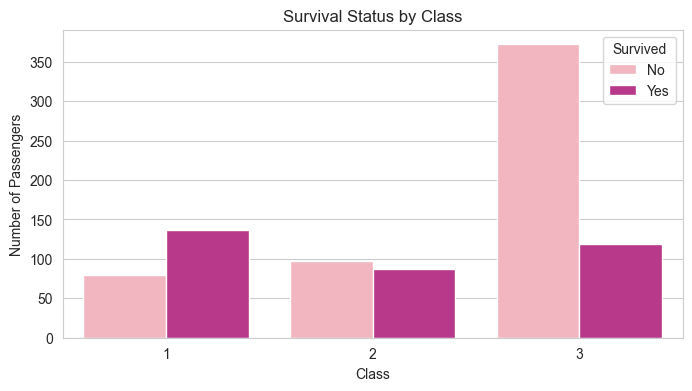

In [20]:
df_grouped = titanic_mapped.groupby(['Pclass', 'Survived']).size().reset_index(name='Count')
plt.figure(figsize=(8,4))
sns.barplot(df_grouped, x='Pclass', y='Count', hue='Survived', palette='RdPu')
plt.xlabel('Class')
plt.ylabel('Number of Passengers')
plt.title('Survival Status by Class')

The violin plot shows that children had a higher chance of survival, while elderly passengers had lower chances. The plot on the right is slightly thinner at the top and wider at the bottom compared to the plot on the left.

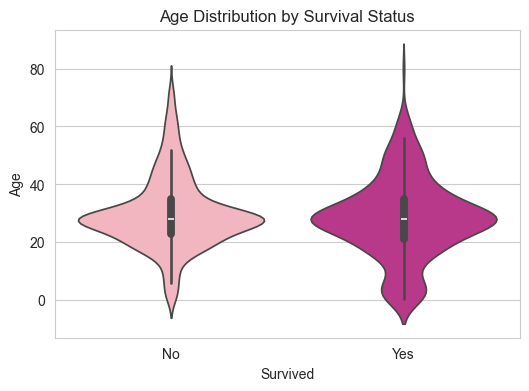

In [21]:
plt.figure(figsize=(6,4))
sns.violinplot(data=titanic_mapped, x='Survived', y='Age',palette='RdPu',hue='Survived', legend=False)
plt.title('Age Distribution by Survival Status')
plt.show()

In [22]:
titanic_df.to_csv('data/titanic_cleaned.csv', index='PassengerId')

# Part II. Machine Learning Modeling
## Data Standardization
Most of the columns have small number values, except for columns `Age` and `Fare`. They need to be normalized, so the model doesn't favor them. Column `Fare` is strongly right-skewed and has some values very much greater than others, so I will apply log transformation to reduce skewness and limit influence of the outliers.

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

RANDOM_STATE = 42

In [24]:
titanic_df['Fare'] = np.log1p(titanic_df['Fare'])

y = titanic_df['Survived']
X = titanic_df.drop(['Survived'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, shuffle=True, random_state=RANDOM_STATE, stratify=y)
scaler = StandardScaler()
X_train[['Fare', 'Age']] = scaler.fit_transform(X_train[['Fare', 'Age']])
X_test[['Fare', 'Age']] = scaler.transform(X_test[['Fare', 'Age']])
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,
693,3,0,-0.112078,0,0,1.194348,1,1,0,0,1
482,2,0,-0.112078,0,0,-3.172090,1,1,0,0,1
528,1,0,-0.112078,0,0,2.654029,1,1,0,0,1
856,3,1,-0.879807,0,1,-0.653573,2,0,0,0,1
802,2,1,0.118241,1,1,0.389691,3,0,0,0,1


## Dataset balance
Before creating ML models, it is useful to check how imbalanced the dataset is. Titanic dataset after preprocessing is slightly imbalanced: 38.38% of survivors and 61.62% of non-survivors.

In [25]:
grouped = titanic_df.groupby('Survived').size()
total = titanic_df.shape[0]
percent_dead = grouped.iloc[0]/total * 100
percent_alive = 100 - percent_dead
print("Percent of survivors: ", round(percent_alive,2), "%")
print("Percent of non-survivors: ", round(percent_dead,2), "%")

Percent of survivors:  38.38 %
Percent of non-survivors:  61.62 %


## Metrics for Data Evaluation
To compare the trained models, I will use f1 score + accuracy. I decided to use f1 score with parameter average='macro'. This means that f1 score will by calculated as the average of the F1 score of each class. In case of a slightly imbalanced set like Titanic, accuracy would not be sufficient.

In [26]:
results = []

## Creating baseline dummy
Creating a baseline model using a DummyClassifier with the stratified strategy. Since the dataset is slightly imbalanced, this approach preserves the class distribution in predictions, providing a more realistic baseline to compare against.

              precision    recall  f1-score   support

         0.0       0.60      0.64      0.62       110
         1.0       0.37      0.33      0.35        69

    accuracy                           0.52       179
   macro avg       0.48      0.48      0.48       179
weighted avg       0.51      0.52      0.52       179



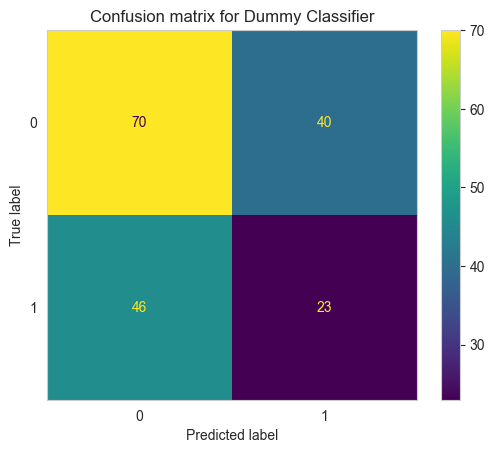

In [27]:
def show_confusion_matrix(cm, name):
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
    cm_display.plot()
    plt.title(f"Confusion matrix for {name}")
    plt.gca().grid(False)
    plt.show()

def evaluate(model, X_test, y_test, name, append_to_results=True):
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    matrix = confusion_matrix(y_test, y_pred)
    if append_to_results:
        results.append({
            "Model":name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1 score": f1_score(y_test, y_pred, average="macro")
        })
    show_confusion_matrix(matrix, name)

model = DummyClassifier(strategy = 'stratified', random_state=RANDOM_STATE)
model.fit(X_train, y_train)
evaluate(model, X_test, y_test, "Dummy Classifier")

## SVM
First ML model I will use is SVM classifier. It is used mainly for classification. It finds the best hyperplane that separates different classes. The default hyperparameters are: C=1.0, kernel='rbf', gamma='scale' and class_weight=None

In [28]:
from sklearn.svm import SVC

clf = SVC()
clf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Inferring on test data
The model performs quite well on the test data, achieving an accuracy of 0.82. However, its performance is lower for class 1, likely due to the smaller number of samples representing this class in the dataset.

              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86       110
         1.0       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



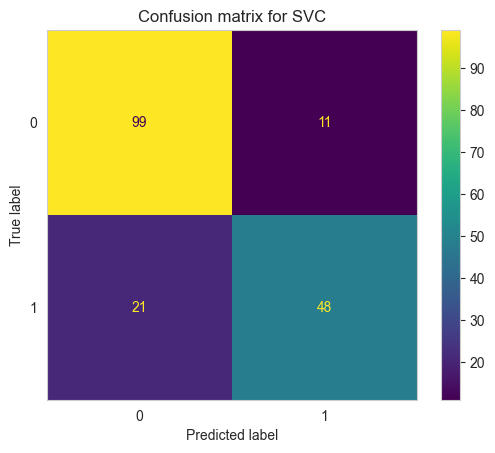

In [29]:
evaluate(clf, X_test, y_test, 'SVM')

### Inferring on train data
The model performs slightly better on the training data, achieving an accuracy of 0.83 compared to 0.82 on the test set. This small difference suggests that there is no significant overfitting and that the model generalizes reasonably well.

              precision    recall  f1-score   support

         0.0       0.84      0.90      0.86       439
         1.0       0.81      0.72      0.76       273

    accuracy                           0.83       712
   macro avg       0.82      0.81      0.81       712
weighted avg       0.83      0.83      0.82       712



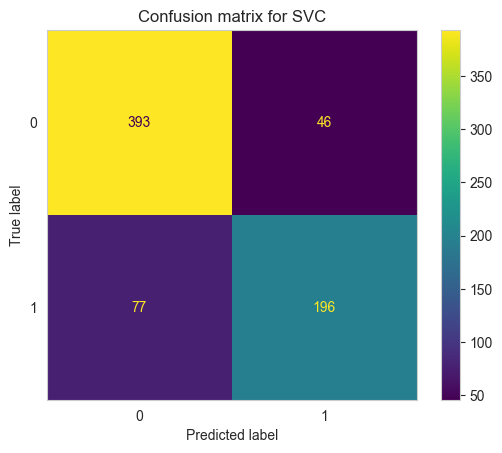

In [30]:
evaluate(clf, X_train, y_train, "SVM", append_to_results=False)

### Hyperparameter tuning
I decided to tune the model by optimizing the hyperparameters C, gamma, and class_weight. The best performing configuration  was found to be: C=1, gamma=0.1, class_weight=None.

In [31]:
param_grid = {
    'C' : [0.1,1,10,100,1000],
    'gamma' : [1, 0.1, 0.01, 0.001, 0.0001],
    'class_weight' : [None, 'balanced']
}
grid = GridSearchCV(SVC(), param_grid=param_grid, verbose=3)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END .C=0.1, class_weight=None, gamma=1;, score=0.650 total time=   0.0s
[CV 2/5] END .C=0.1, class_weight=None, gamma=1;, score=0.636 total time=   0.0s
[CV 3/5] END .C=0.1, class_weight=None, gamma=1;, score=0.627 total time=   0.0s
[CV 4/5] END .C=0.1, class_weight=None, gamma=1;, score=0.634 total time=   0.0s
[CV 5/5] END .C=0.1, class_weight=None, gamma=1;, score=0.641 total time=   0.0s
[CV 1/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.748 total time=   0.0s
[CV 2/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.790 total time=   0.0s
[CV 3/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.789 total time=   0.0s
[CV 4/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.796 total time=   0.0s
[CV 5/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.796 total time=   0.0s
[CV 1/5] END C=0.1, class_weight=None, gamma=0.01;, score=0.615 total time=   0.0s
[CV 2/5] END C=0.1, class_weight=None, g

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'class_weight': [None, 'balanced'], 'gamma': [1, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3

### Creating a model with best estimator
The results obtained with the default SVM classifier and the tuned model are extremely similar, with the tuned model having 2 more false positives.

              precision    recall  f1-score   support

         0.0       0.82      0.88      0.85       110
         1.0       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



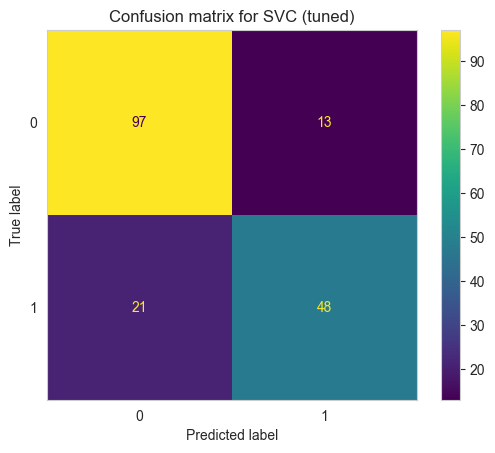

In [32]:
# creating model with best hyperparameters
clf_tuned = grid.best_estimator_
clf_tuned.fit(X_train, y_train)
evaluate(clf_tuned, X_test, y_test, "SVM (tuned)")

### Summary of SVM
The SVM classifier outperforms the Dummy Classifier; however, the accuracy remains below 82%. Hyperparameter tuning resulted in no improvements.
## Decision Tree
It's trained using default parameters, without restricting the maximum depth of the tree. While this allows the model to fully adapt to the training data, it may lead to overfitting, as the tree can become overly complex and capture noise rather than general patterns.

In [33]:
model = DecisionTreeClassifier(random_state=RANDOM_STATE)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

### Inferring on test data

              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84       110
         1.0       0.76      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



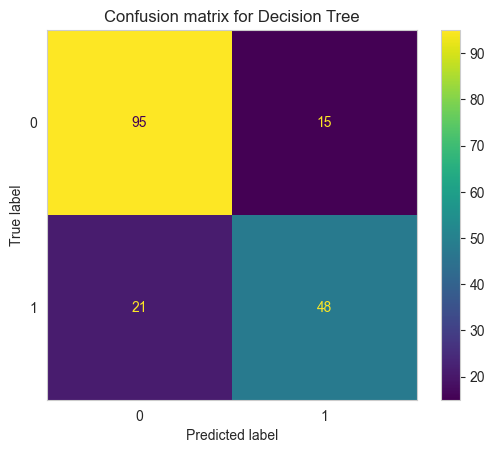

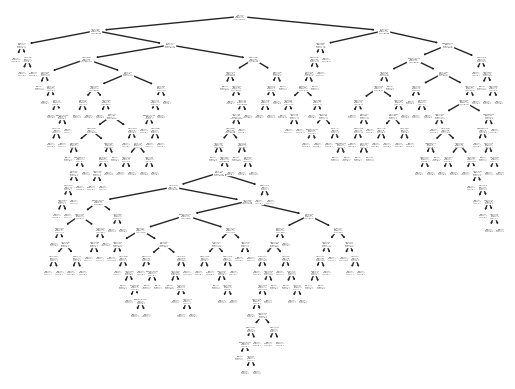

In [34]:
evaluate(model, X_test, y_test, "Decision Tree")

from sklearn import tree
tree.plot_tree(model,feature_names=list(X_test.columns))
plt.show()

### Inferring on train data
As expected, overfitting occurs. Inferring on test data showed 0.80 accuracy, while inferring on train data is 0.98. I will assign max_depth=3 to prevent overfitting.

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98       439
         1.0       0.99      0.96      0.97       273

    accuracy                           0.98       712
   macro avg       0.98      0.98      0.98       712
weighted avg       0.98      0.98      0.98       712



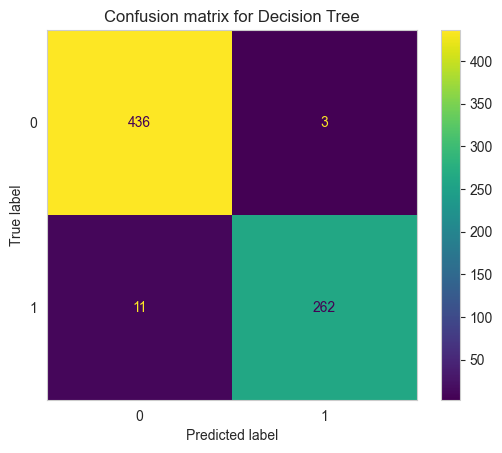

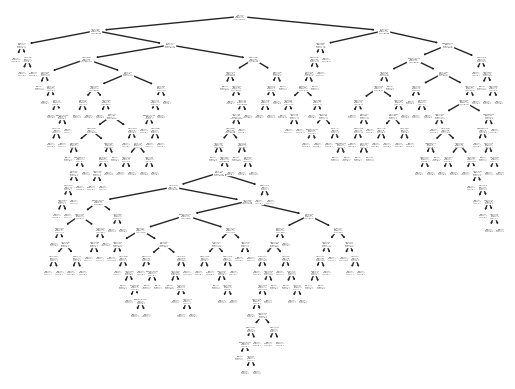

In [35]:
evaluate(model, X_train, y_train, "Decision Tree", append_to_results=False)

tree.plot_tree(model,feature_names=list(X_test.columns))
plt.show()

### Decision Tree with max_depth=3, Inferring on Test Data

              precision    recall  f1-score   support

         0.0       0.80      0.90      0.85       110
         1.0       0.80      0.65      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



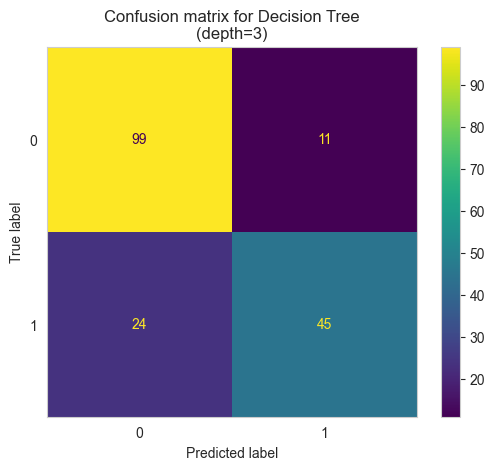

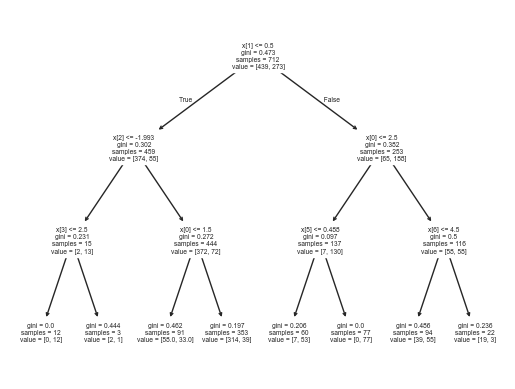

In [36]:
model = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
model.fit(X_train, y_train)
evaluate(model, X_test, y_test, "Decision Tree\n(depth=3)")
tree.plot_tree(model)
plt.show()

### Inferring on Train Data

              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87       439
         1.0       0.81      0.72      0.76       273

    accuracy                           0.83       712
   macro avg       0.82      0.81      0.81       712
weighted avg       0.83      0.83      0.83       712



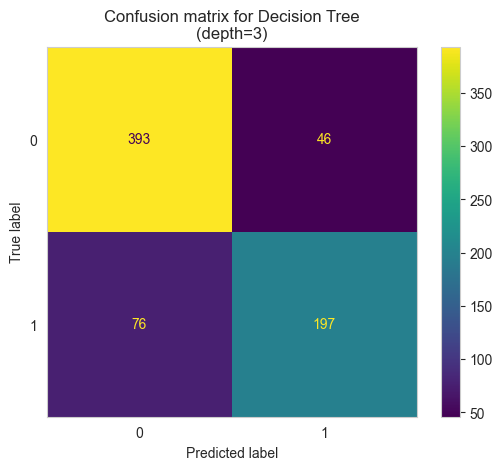

In [37]:
evaluate(model, X_train, y_train, "Decision Tree\n(depth=3)", append_to_results=False)

### Hyperparameter tuning
With max_depth=3 I managed to reduce the overfitting, although the model still performs slightly better on the training data, which is expected.

However, the overall performance of the tuned model is slightly worse than the default configuration, with a lower accuracy on the test set. This may occur because the dataset is relatively small, making the results sensitive to small changes in model parameters. Hyperparameter tuning selects the best configuration based on cross-validation on the training data, but the parameters that perform best during cross-validation do not always generalize better to the unseen test set. As a result, the tuned model can sometimes achieve slightly worse accuracy despite reducing overfitting.

Fitting 5 folds for each of 2430 candidates, totalling 12150 fits
[CV 1/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.790 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.762 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.796 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.810 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.789 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=4;, score=0.790 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=4;, score=0.762 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=4;, score=0.796 total time=   0.0s
[CV 4/5] END c

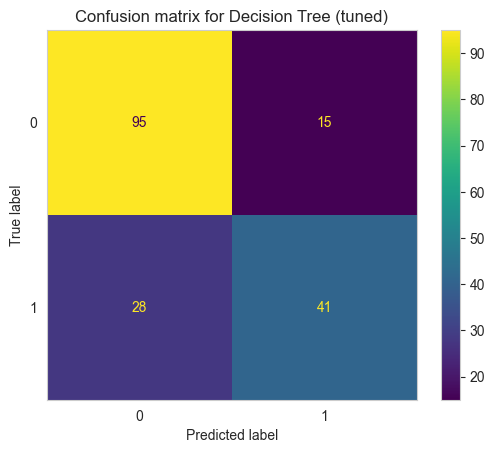

In [38]:
param_grid = {
    'max_depth' : range(1,10),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion' : ['gini', 'entropy', 'log_loss'],
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), param_grid=param_grid, verbose=3)
grid.fit(X_train, y_train)
model = grid.best_estimator_
evaluate(model, X_test, y_test, "Decision Tree (tuned)")

# Part III. Summary and Conclusions
## Model Comparison
The table below summarizes the performance of all trained models on the test set. Accuracy alone can be misleading for imbalanced datasets, therefore F1-score is also included as a more balanced metric.

In [39]:
results = pd.DataFrame(results)
results[['Accuracy', 'F1 score']] = results[['Accuracy', 'F1 score']].round(2)
print(results)

                      Model  Accuracy  F1 score
0          Dummy Classifier      0.52      0.48
1                       SVC      0.82      0.81
2               SVC (tuned)      0.81      0.79
3             Decision Tree      0.80      0.78
4  Decision Tree\n(depth=3)      0.80      0.78
5     Decision Tree (tuned)      0.76      0.74


## Visualization: Model Accuracy Comparison

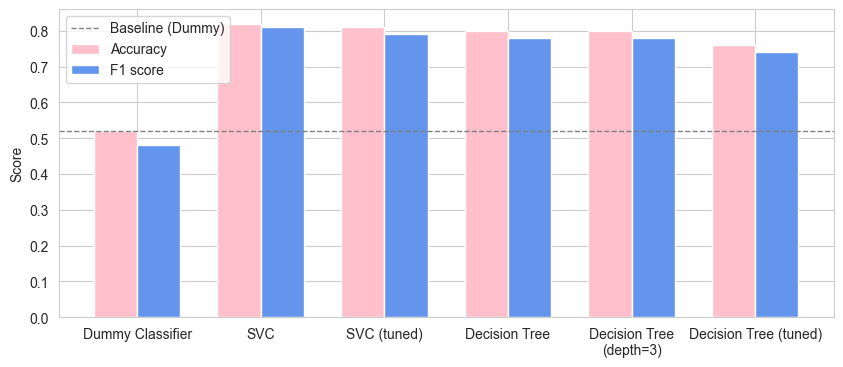

In [56]:
plt.figure(figsize=(10,4))
x = np.arange(len(results['Model']))
width = 0.35
plt.bar(x - width/2, results['Accuracy'], width,  color='pink', label='Accuracy')
plt.bar(x + width/2, results['F1 score'], width, color='cornflowerblue', label= 'F1 score')
plt.xticks(x, results['Model'])
plt.axhline(y=results.loc[0, 'Accuracy'], color='gray', linestyle='--', linewidth=1, label='Baseline (Dummy)')
plt.ylabel('Score')
plt.legend()
plt.show()


## Key Findings

 **Preprocessing:**
 - Missing values in `Age` and `Fare` were replaced with the median, which is preferred with the right-skewed distribution
 - The `Cabin` column was dropped due to over 77% missing values
 - Feature engineering introduced `FamilySize` and `IsAlone`
 - Log transformation was applied to `Fare` before scaling to reduce the influence of
   extreme outliers

 **Exploratory Analysis:**
 - Gender was a strong predictor of survival: women survived at a
   significantly higher rate than men
 - Passenger class showed a clear survival gradient - 1st class passengers had
   the highest survival rate, 3rd class the lowest
 - Age distribution suggested that children had slightly better survival chances than elderly passengers

 **Modeling:**
 - All trained models outperformed the Dummy Classifier baseline,
   confirming that the models have learned meaningful patterns from the data
 - SVM with default hyperparameters achieved 0.82 accuracy and generalized well,
   with only a small gap between train and test performance
 - Hyperparameter tuning of SVM did not improve results, suggesting the default configuration was already well-suited to this dataset
 - The default Decision Tree suffered from severe overfitting (train accuracy: 0.98,
   test accuracy: 0.80). Constraining tree depth to 3 resolved this issue
 - The tuned Decision Tree achieved the worst accuracy

 ## Limitations and Potential Improvements

 - The `Cabin` column was dropped entirely; extracting the **deck letter** as a feature
   could potentially improve predictions, given that deck level may correlate with
   evacuation access
 - Only two model families were explored. Adding **Random Forest** or **Gradient Boosting** could improve performance further and provide a better comparison
 - Model evaluation relied on a single train/test split. Applying **k-fold
   cross-validation** would provide more reliable performance estimates
